In [1]:
import os
import torch
import time
import subprocess
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from adj import main, combine_graph_dict
from train import train_model
from utils import mclust_R, fix_seed

In [2]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from sklearn.metrics import v_measure_score as v_score
from utils import compute_PAS, compute_CHAOS
from sklearn.decomposition import PCA

In [3]:
fix_seed(42)

In [4]:
data_root = Path('../../Data/ARTISTA')

proj_list = [
    'Stage44', 'Stage54', 'Stage57'
]

#12, 14, 13, 13, 13

In [5]:
for proj_name in tqdm(proj_list):
    adata_tmp = sc.read_h5ad(os.path.join(data_root, proj_name + '.h5ad'))
    #print(len(adata_tmp.obs))
    adata_tmp.var_names_make_unique()

    adata_tmp.obs['batch_name'] = proj_name
    graph_dict_tmp = main(adata_tmp, adj_cons_by='coordinate', distType='KNN', k_cutoff=8, rad_cutoff=250)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    #adata_tmp= adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]
    
    if proj_name == proj_list[0]:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['proj_name'] = proj_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['proj_name'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + proj_name

  0%|          | 0/3 [00:00<?, ?it/s]

------Calculating spatial graph...


 33%|███▎      | 1/3 [00:00<00:01,  1.67it/s]

The graph contains 11816 edges, 1477 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 23432 edges, 2929 cells.
8.0000 neighbors per cell on average.


 67%|██████▋   | 2/3 [00:01<00:01,  1.04s/it]

------Calculating spatial graph...
The graph contains 35280 edges, 4410 cells.
8.0000 neighbors per cell on average.


100%|██████████| 3/3 [00:04<00:00,  1.56s/it]


In [6]:
adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=3000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [7]:
start_time = time.time()

sedr_net = train_model(adata, graph_dict, pre_epochs=500 ,epochs=1000, mask_rate=0.2)
using_dec = True
if using_dec:
    sedr_net.train_with_dec(num_aggre=1)
else:
    sedr_net.train_without_dec()
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total running time: {elapsed_time:.2f} seconds")

# 通过nvidia-smi命令查询GPU显存占用
def get_gpu_memory():
    try:
        result = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.used,memory.total', '--format=csv,nounits,noheader'],
            encoding='utf-8'
        )
        gpu_usages = result.strip().split('\n')
        for idx, usage in enumerate(gpu_usages):
            used, total = usage.split(', ')
            print(f"GPU {idx}: {used} MiB / {total} MiB")
    except Exception as e:
        print("Could not query GPU memory usage:", e)

get_gpu_memory()

Epoch 499 total loss=5.798: 100%|██████████ [ time left: 00:00 ]     
Epoch 999 total loss=3.625 recon loss=3.102 kl loss=0.030 tri loss=0.220 : |           [ time left: 00:00 ]    


Total running time: 160.29 seconds
GPU 0: 4680 MiB / 24564 MiB


In [8]:
sedr_feat, _ = sedr_net.process()
adata.obsm['SpaBatch'] = sedr_feat

In [9]:
mclust_R(adata, num_cluster=17, used_obsm='SpaBatch')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 8816 × 3000
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'Annotation', 'batch_name', 'proj_name', 'batch', 'mclust'
    var: 'Gene', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'X_pca', 'X_spatial', 'spatial', 'Tri_SEDR', 'SpaBatch'
    layers: 'counts', 'count'

In [10]:
#adata.write("Ours_DLPFC_MOE1")

In [11]:
#adata = sc.read_h5ad('Ours_DLPFC_MOE1')

In [12]:
sub_adata = adata[~pd.isnull(adata.obs['Annotation'])]
ARI = ari_score(sub_adata.obs['Annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['Annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.44081235216414655
Stage44 ARI:0.3986130090343138
Stage54 ARI:0.4660107415229297
Stage57 ARI:0.5676442484777265


In [13]:
sub_adata = adata[~pd.isnull(adata.obs['Annotation'])]
NMI = nmi_score(sub_adata.obs['Annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['Annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} NMI:{NMI}")

total NMI:0.6547172081162669
Stage44 NMI:0.5856746684810715
Stage54 NMI:0.6769923615286952
Stage57 NMI:0.7416932199689278


In [14]:
sub_adata = adata[~pd.isnull(adata.obs['Annotation'])]
HOM = hom_score(sub_adata.obs['Annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['Annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} HOM:{HOM}")

total HOM:0.6685182700408052
Stage44 HOM:0.6359117965085229
Stage54 HOM:0.6929268822926226
Stage57 HOM:0.7453153124916092


In [15]:
import scib

sc.pp.neighbors(adata, use_rep="SpaBatch")
scib.me.graph_connectivity(adata, label_key="Annotation")

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() inste

0.9779942281394042

In [16]:
scib.me.silhouette_batch(adata, batch_key="batch_name", label_key="Annotation", embed="SpaBatch")

mean silhouette per group:                  silhouette_score
group                            
CP                       0.729818
Immature CMPN            0.807880
Immature MSN             0.735549
Immature cckIN           0.600175
Immature dpEX            0.851674
Immature mpEX            0.732740
Immature nptxEX          0.868896
VLMC                     0.874743
dEGC                     0.884244
dNBL1                    0.811871
dNBL2                    0.886851
dNBL4                    0.861931
dNBL5                    0.804979
sfrpEGC                  0.808943
wntEGC                   0.915753


0.8117364909301141

In [17]:
# import harmonypy as hm

# iLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
# cLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
# df_iLISI = pd.DataFrame({
#     'method': 'SEDR',
#     'value': iLISI,
#     'type': ['ILISI'] * len(iLISI)
# })

# df_cLISI = pd.DataFrame({
#     'method': 'SEDR',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

# fig, axes = plt.subplots(1, 2, figsize=(4, 5))
# sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
# sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
# axes[0].set_ylim(1, 3)
# axes[1].set_ylim(1, 7)
# axes[0].set_title('iLISI')
# axes[1].set_title('cLISI')

# plt.tight_layout()
# print(np.median(iLISI))
# print(np.median(cLISI))

In [18]:
# import matplotlib.pyplot as plt
# 
# plt.figure(figsize=(11, 10))
# k = 1
# spot_size = 2
# for slice_id, slice_name in enumerate(proj_list):
#     adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
#     ax = plt.subplot(2, 4, k)
#     # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
#     sc.pl.spatial(adata_tmp, img_key=None, color=['annotation'], title=[''],
#                   legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
#                   spot_size=spot_size)
#     plt.title(f'{slice_name}')
#     k += 1
# plt.tight_layout()

In [19]:
# adata = sc.read_h5ad('Ours_DLPFC_MOE1')

# proj_list = [
#     'E9.5_E1S1.MOSTA', 'E9.5_E2S1.MOSTA', 'E9.5_E2S2.MOSTA', 'E9.5_E2S3.MOSTA', 'E9.5_E2S4.MOSTA'
# ]

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key]

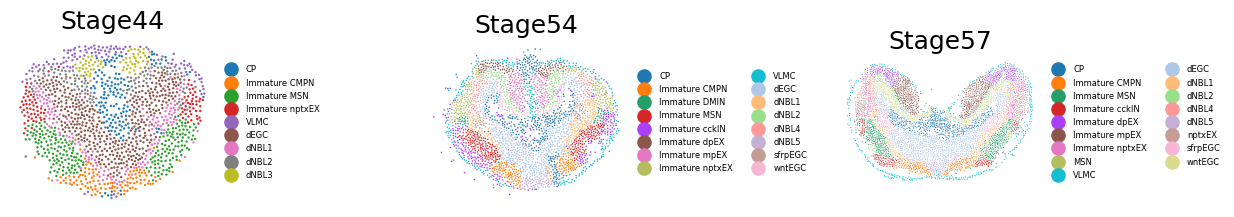

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 20
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['Annotation'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key]

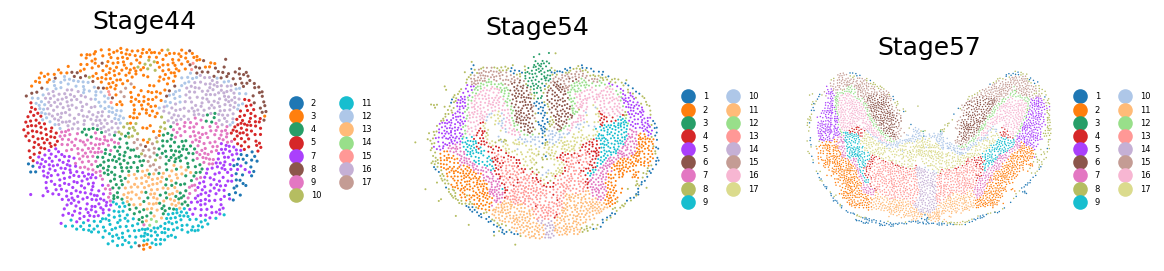

In [21]:
plt.figure(figsize=(15, 10))
k = 1
spot_size = 20
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key]

<Figure size 1500x1000 with 0 Axes>

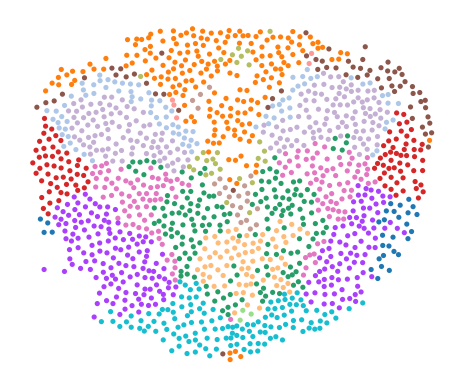

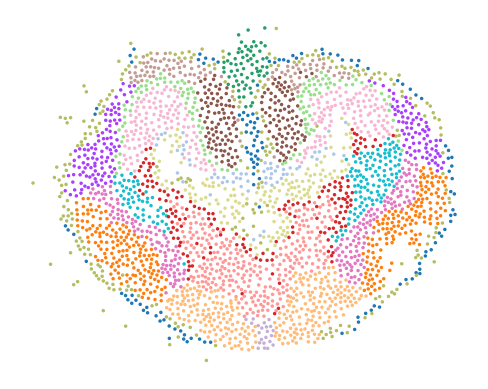

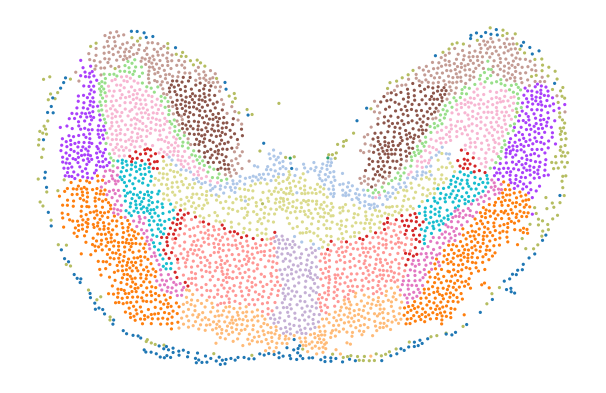

In [22]:
plt.figure(figsize=(15, 10))
k = 1
spot_size = 20
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc=None, legend_fontsize=6, show=False, frameon=False,
                  spot_size=spot_size)
    #plt.title(f'{slice_name}')
    #plt.savefig(f'Spatial_SpaBatch_{slice_name}.jpg', bbox_inches='tight', dpi=300)
    k += 1
plt.tight_layout()

<Figure size 1500x1000 with 0 Axes>

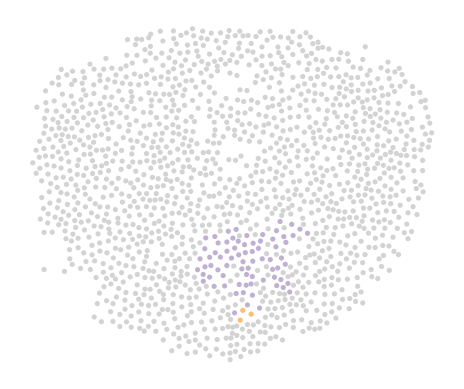

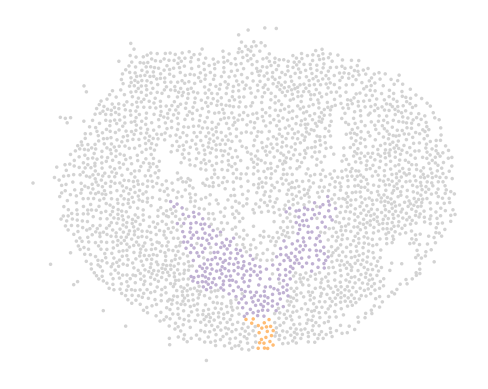

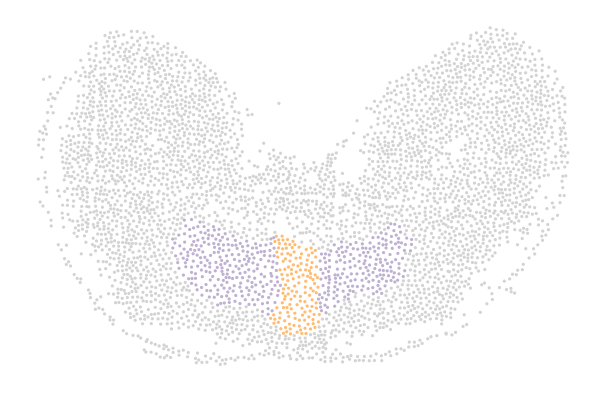

In [30]:
import matplotlib.pyplot as plt
import scanpy as sc

# 1. 定义你想要高亮的类别和颜色映射
highlight_clusters = ['13', '14']  # 确保这里是字符串，如果 mclust 是整数请去掉引号
# 设置颜色：4 为一种颜色，7 为一种颜色，其他全部为浅灰色
# 你可以根据需要修改这里的颜色代码
palette = {
    '14': '#ffbc73',   # 红色
    '13': '#c0b1d3',   # 蓝色
    'Others': '#D3D3D3' # 浅灰色
}

plt.figure(figsize=(15, 10))
spot_size = 20

for slice_id, slice_name in enumerate(proj_list):
    # 提取当前 Batch 的数据
    adata_tmp = adata[adata.obs['batch_name'] == slice_name].copy()
    
    # 2. 创建一个临时列用于绘图
    # 默认将所有值设为 'Others'
    adata_tmp.obs['plot_clusters'] = 'Others'
    
    # 将属于 4 和 7 的点保留原样（转换为字符串以匹配 palette）
    mask = adata_tmp.obs['mclust'].astype(str).isin(highlight_clusters)
    adata_tmp.obs.loc[mask, 'plot_clusters'] = adata_tmp.obs.loc[mask, 'mclust'].astype(str)
    
    # 3. 确保 plot_clusters 是分类类型，并按顺序设置颜色
    adata_tmp.obs['plot_clusters'] = adata_tmp.obs['plot_clusters'].astype('category')
    
    # 调用绘图
    # 使用 ax 控制子图布局（如果需要并排显示）
    #ax = plt.subplot(2, 3, slice_id + 1) # 假设 6 个切片 2x3 布局
    
    sc.pl.spatial(
        adata_tmp, 
        img_key=None, 
        color='plot_clusters', 
        title='',
        palette=palette,  # 传入自定义颜色映射
        legend_loc=None, 
        show=False, 
        frameon=False,
        spot_size=spot_size,
        #ax=ax
    )
    plt.savefig(f"Spatial_dEGC_cells_{slice_name}.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()